# Crime Hotspot Detection Using Spatio Temporal Machine Learning

# 1.Importing Libraries

In [2]:
import pandas as pd                   ## Python library to work with tabular data
import numpy as np                    ## Python library for numerical computing
import matplotlib.pyplot as plt       ## Pythonlibrary for Data Visualization
%matplotlib inline
import seaborn as sns                 ## Python library for Data Visualization
import warnings                       ##to ignore warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objs as go



In [3]:
import pandas as pd
df=pd.read_csv("/Users/bhanuprasanthmarisetty/Downloads/S3180490-Artifact/Crime_Data_from_2020_to_Present.csv")

df_crime=df

In [4]:
# getting information of data with info() method
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317854 entries, 0 to 317853
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           317854 non-null  int64  
 1   Date Rptd       317854 non-null  object 
 2   DATE OCC        317854 non-null  object 
 3   TIME OCC        317854 non-null  int64  
 4   AREA            317854 non-null  int64  
 5   AREA NAME       317854 non-null  object 
 6   Rpt Dist No     317854 non-null  int64  
 7   Part 1-2        317854 non-null  int64  
 8   Crm Cd          317854 non-null  int64  
 9   Crm Cd Desc     317854 non-null  object 
 10  Mocodes         274531 non-null  object 
 11  Vict Age        317854 non-null  int64  
 12  Vict Sex        276448 non-null  object 
 13  Vict Descent    276443 non-null  object 
 14  Premis Cd       317849 non-null  float64
 15  Premis Desc     317746 non-null  object 
 16  Weapon Used Cd  116477 non-null  float64
 17  Weapon Des

In [5]:
# getting top features of dataset
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,...,AO,Adult Other,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,330,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,700 S HILL ST,NaN,34.0459,-118.2545
2,201220752,09/16/2020 12:00:00 AM,09/16/2020 12:00:00 AM,1230,12,77th Street,1259,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,700 E 73RD ST,NaN,33.9739,-118.2630
3,191501505,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,1730,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,998.0,NaN,NaN,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,415,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,Invest Cont,740.0,NaN,NaN,NaN,14400 TITUS ST,NaN,34.2198,-118.4468


In [6]:
#getting bottom features of dataset
df.tail()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
317849,211208872,03/19/2021 12:00:00 AM,03/19/2021 12:00:00 AM,1105,12,77th Street,1218,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,58TH ST,FIGUEROA ST,33.9897,-118.2827
317850,210506531,03/04/2021 12:00:00 AM,03/04/2021 12:00:00 AM,2210,5,Harbor,564,2,434,FALSE IMPRISONMENT,...,AA,Adult Arrest,434.0,NaN,NaN,NaN,200 W 2ND ST,NaN,33.7424,-118.2814
317851,211710505,07/09/2021 12:00:00 AM,07/09/2021 12:00:00 AM,1050,17,Devonshire,1798,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,8800 DEMPSEY AV,NaN,34.2302,-118.4775
317852,210312887,07/12/2021 12:00:00 AM,07/12/2021 12:00:00 AM,1200,3,Southwest,363,1,350,"THEFT, PERSON",...,IC,Invest Cont,350.0,NaN,NaN,NaN,CRENSHAW BL,STOCKER ST,34.0088,-118.3351
317853,212005847,02/22/2021 12:00:00 AM,02/22/2021 12:00:00 AM,1200,20,Olympic,2034,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3300 W 8TH ST,NaN,34.0596,-118.3022


In [7]:
 # Prints only numerical columns of the dataframe
 df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,3.178540e+05,317854.000000,317854.000000,317854.000000,317854.000000,317854.000000,317854.000000,317849.000000,116477.000000,317851.000000,25981.000000,880.000000,30.000000,317854.000000,317854.000000
mean,2.050625e+08,1352.762504,10.798860,1126.046200,1.412765,508.928842,30.073348,294.451117,362.523777,508.657604,955.427428,982.376136,989.866667,33.825098,-117.495603
std,4.965168e+06,650.001432,6.039124,604.005822,0.492332,210.338553,21.716577,212.949440,123.158198,210.125700,116.066327,53.633150,34.225150,2.893775,10.044824
min,8.170000e+02,1.000000,1.000000,101.000000,1.000000,110.000000,-1.000000,101.000000,101.000000,110.000000,210.000000,626.000000,821.000000,0.000000,-118.667600
25%,2.009132e+08,920.000000,6.000000,628.000000,1.000000,330.000000,12.000000,101.000000,308.000000,330.000000,998.000000,998.000000,998.000000,34.007800,-118.429600
50%,2.018096e+08,1430.000000,11.000000,1149.000000,1.000000,510.000000,31.000000,203.000000,400.000000,510.000000,998.000000,998.000000,998.000000,34.057400,-118.321300
75%,2.108086e+08,1900.000000,16.000000,1621.000000,2.000000,626.000000,45.000000,501.000000,400.000000,626.000000,998.000000,998.000000,998.000000,34.162900,-118.274000
max,2.199178e+08,2359.000000,21.000000,2199.000000,2.000000,956.000000,120.000000,971.000000,516.000000,956.000000,999.000000,999.000000,999.000000,34.334300,0.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df= df.drop(['Weapon Used Cd', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street','Mocodes'], axis=1)
df["Vict Sex"].fillna(df["Vict Sex"].mode()[0],inplace=True)
df["Vict Descent"].fillna(df["Vict Descent"].mode()[0],inplace=True)
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA            0
AREA NAME       0
Rpt Dist No     0
Part 1-2        0
Crm Cd          0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Premis Cd       0
Premis Desc     0
Weapon Desc     0
Status          0
Status Desc     0
Crm Cd 1        0
LOCATION        0
LAT             0
LON             0
dtype: int64

# Exploratory Data analysis

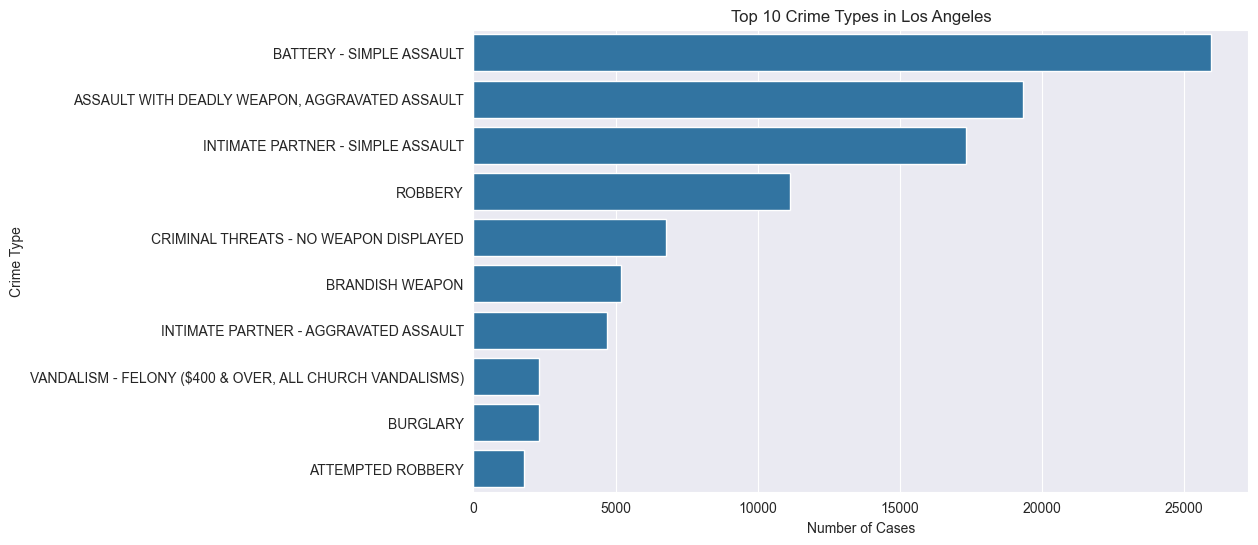

In [11]:
#Top 10 Crimes in los Angeles
top_crimes = df['Crm Cd Desc'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top_crimes.index, x=top_crimes.values)
plt.title("Top 10 Crime Types in Los Angeles")
plt.xlabel("Number of Cases")
plt.ylabel("Crime Type")
plt.show()

In [12]:
# Convert date column
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')

# Extract year and month
df['Year'] = df['DATE OCC'].dt.year
df['Month'] = df['DATE OCC'].dt.month
df['DayOfWeek'] = df['DATE OCC'].dt.day_name()
df['Hour'] = df['DATE OCC'].dt.hour

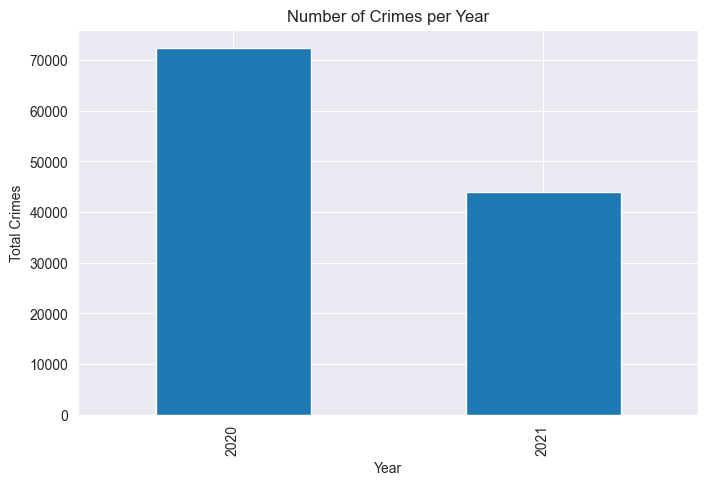

In [13]:
# Crimes per Year
plt.figure(figsize=(8,5))
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Crimes per Year")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.show()

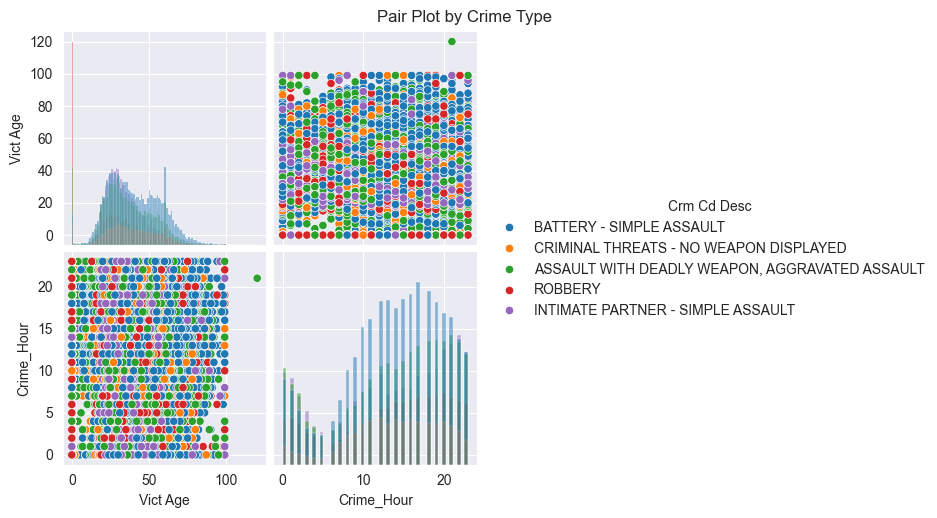

In [14]:
# Filter top 5 crime types
# Create Crime Hour
df['Crime_Hour'] = pd.to_datetime(
    df['TIME OCC'].astype(str).str.zfill(4),
    format='%H%M',
    errors='coerce'
).dt.hour
top_crimes = df['Crm Cd Desc'].value_counts().head(5).index
filtered_df = df[df['Crm Cd Desc'].isin(top_crimes)]
pairplot_df = filtered_df[['Vict Age', 'Crime_Hour', 'Crm Cd Desc']].dropna()

sns.pairplot(pairplot_df, hue='Crm Cd Desc', diag_kind='hist')
plt.suptitle("Pair Plot by Crime Type", y=1.02)
plt.show()


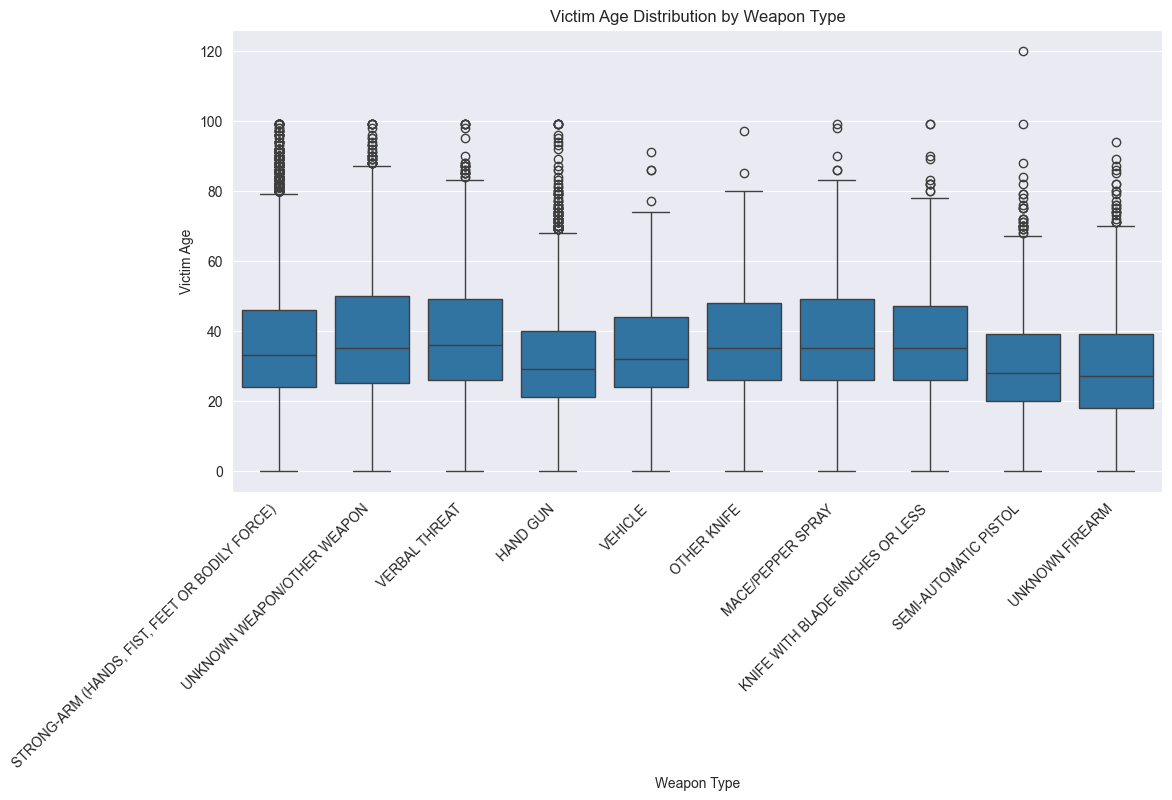

In [15]:
top_weapons = df['Weapon Desc'].value_counts().head(10).index
weapon_df = df[df['Weapon Desc'].isin(top_weapons)]
plt.figure(figsize=(12,6))
sns.boxplot(
    x='Weapon Desc',
    y='Vict Age',
    data=weapon_df
)

plt.title("Victim Age Distribution by Weapon Type")
plt.xlabel("Weapon Type")
plt.ylabel("Victim Age")
plt.xticks(rotation=45, ha='right')
plt.show()

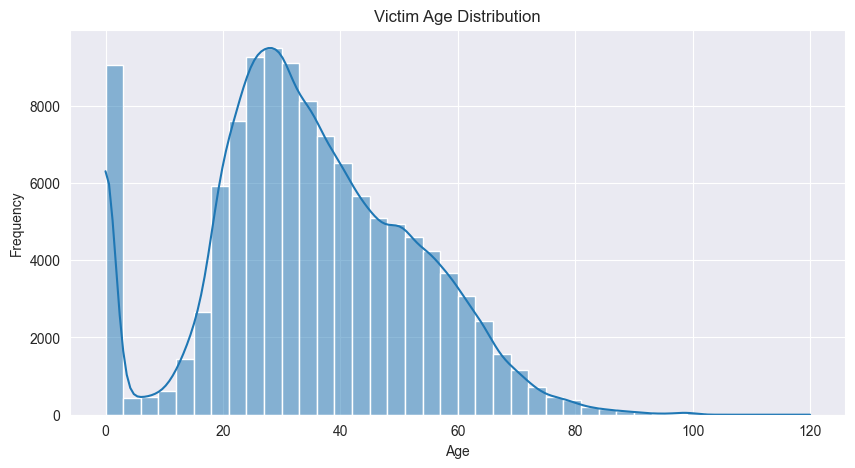

In [16]:
#Victim Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Vict Age'],bins=40,kde=True)
plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

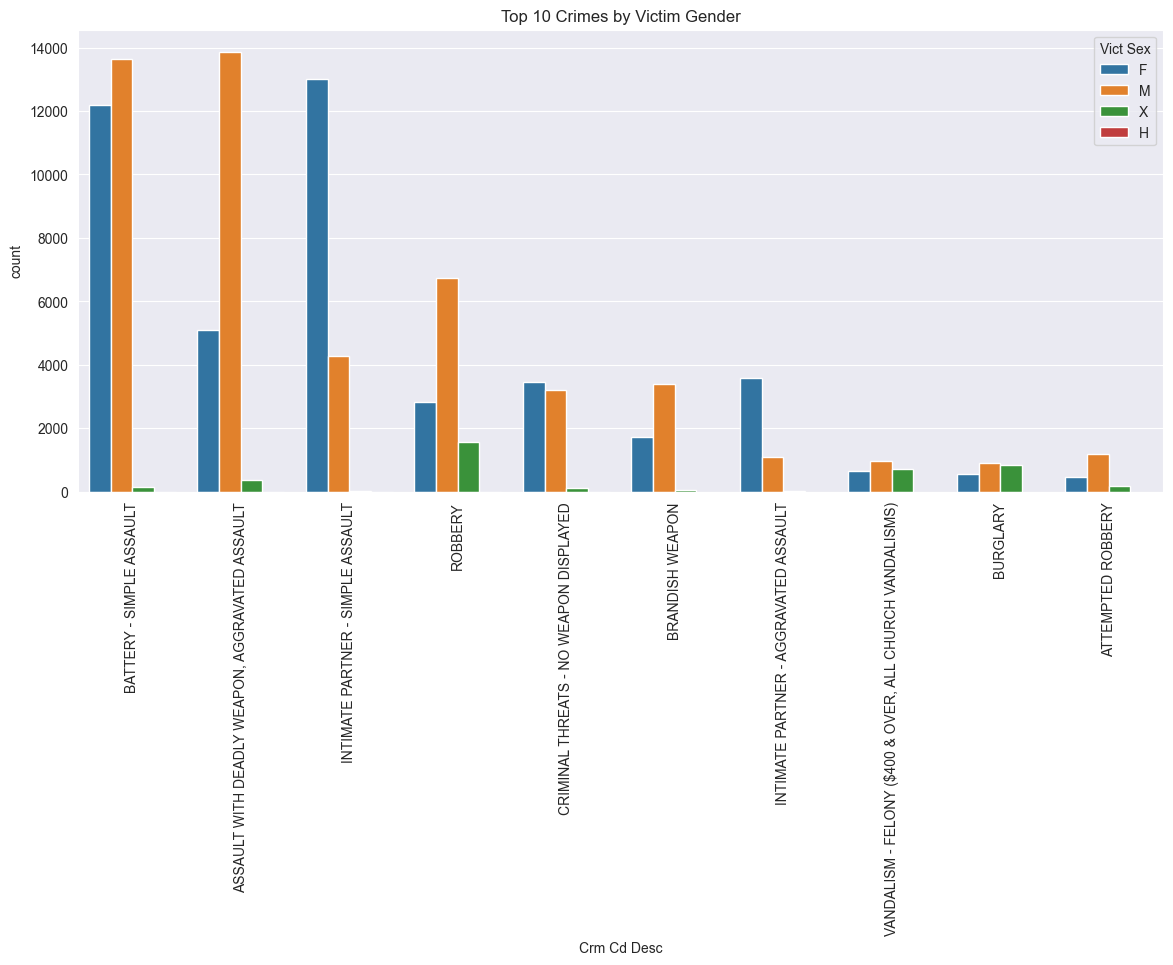

In [17]:
#Crime Category vs Victimgender
plt.figure(figsize=(14,6))
sns.countplot(data=df,x='Crm Cd Desc',hue='Vict Sex',order=df['Crm Cd Desc'].value_counts().head(10).index)
plt.title("Top 10 Crimes by Victim Gender")
plt.xticks(rotation=90)
plt.show()

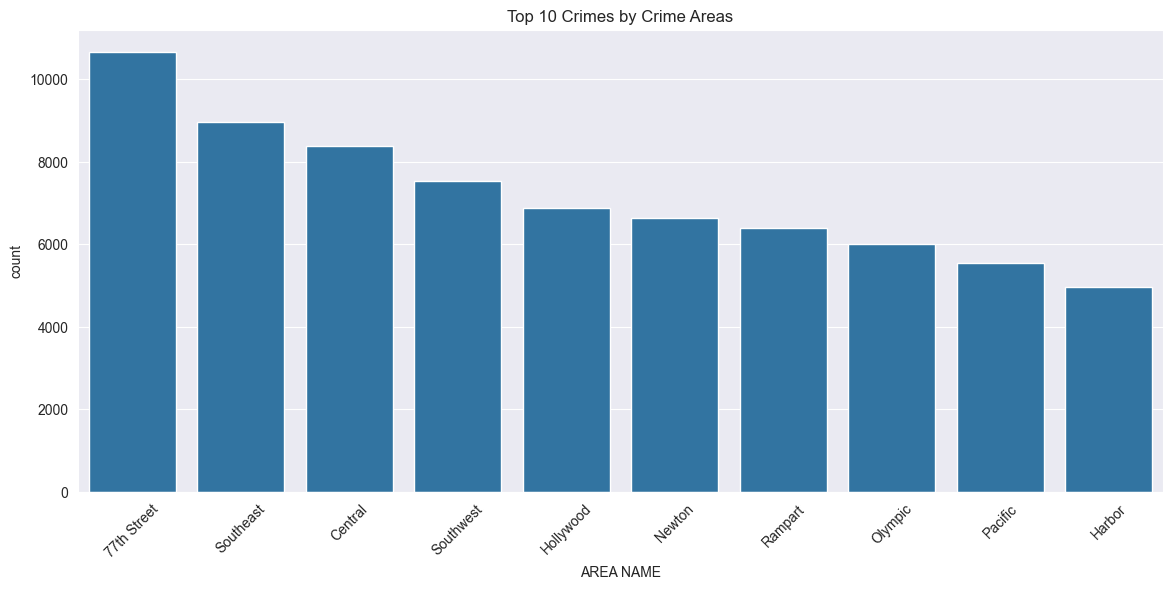

In [18]:
#Crime Category vs Area
plt.figure(figsize=(14,6))
sns.countplot(data=df,x='AREA NAME',order=df['AREA NAME'].value_counts().head(10).index)
plt.title("Top 10 Crimes by Crime Areas")
plt.xticks(rotation=45)
plt.show()

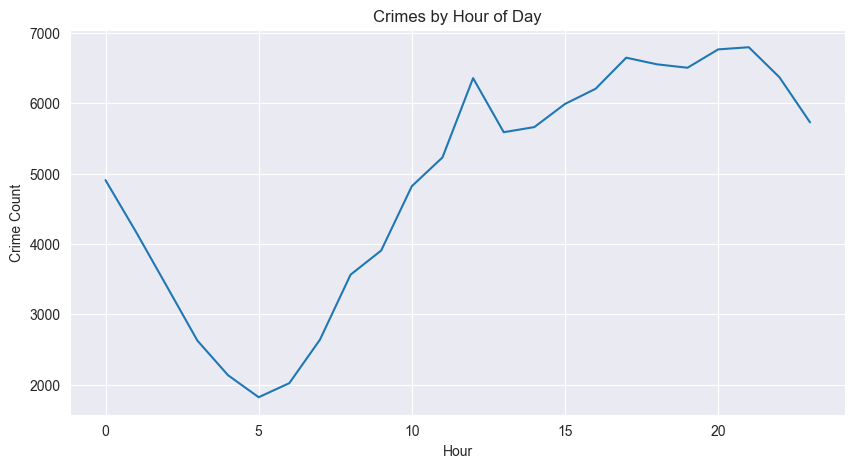

In [19]:
df['HOUR'] = pd.to_datetime(
    df['TIME OCC'].astype(str).str.zfill(4),
    format='%H%M',
    errors='coerce'
).dt.hour

plt.figure(figsize=(10,5))
df['HOUR'].value_counts().sort_index().plot(kind='line')
plt.title("Crimes by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Crime Count")
plt.show()


<Figure size 1200x600 with 0 Axes>

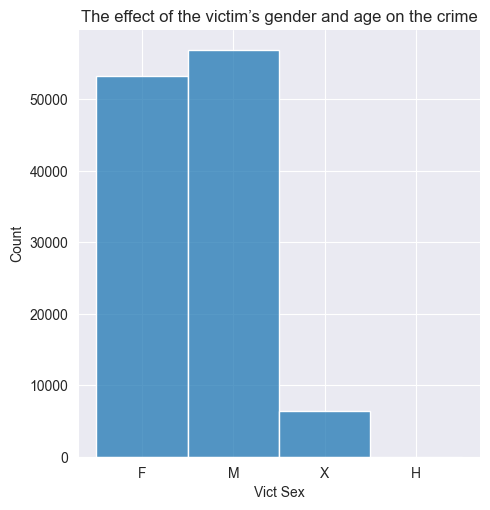

In [20]:
plt.figure(figsize=(12,6))
sns.displot(df['Vict Sex'])
plt.title("The effect of the victim’s gender and age on the crime")
plt.xlabel("Vict Sex")
plt.show()

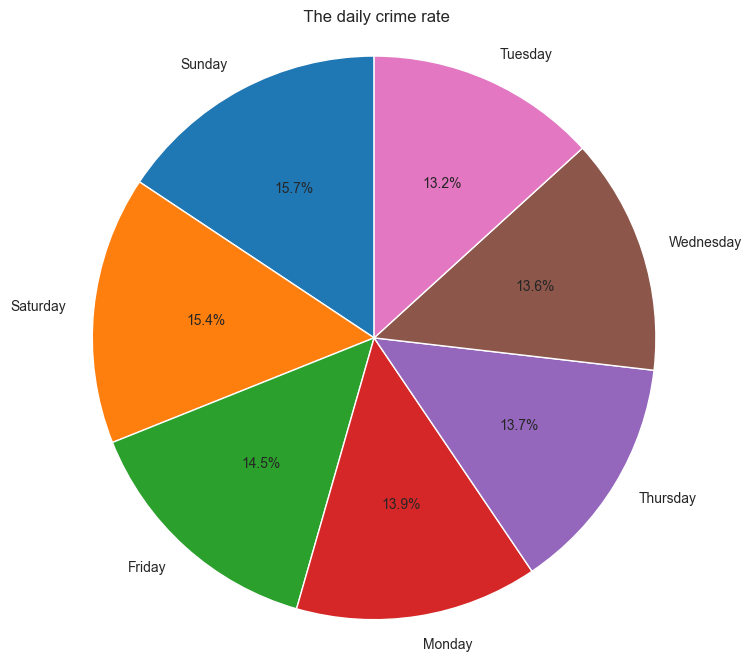

In [21]:
#crimes rates by dates
df['Days'] = df['DATE OCC'].dt.day_name()
C_by_day = df['Days'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(C_by_day.values, labels=C_by_day.index, autopct="%1.1f%%", startangle=90)
plt.title(' The daily crime rate')
plt.axis('equal')
plt.show()

# Target Variable Distribution

In [22]:
import pandas as pd

# 1️⃣ Peak crime hour
peak_hour = df['HOUR'].mode()[0]
peak_hour_count = df[df['HOUR'] == peak_hour].shape[0]

# 2️⃣ Gender distribution
gender_counts = df['Vict Sex'].value_counts()
total = gender_counts.sum()

gender_m_percent = (gender_counts.get('M', 0) / total) * 100
gender_f_percent = (gender_counts.get('F', 0) / total) * 100

# 3️⃣ Create output table
comparison_table = pd.DataFrame({
    "Metric": [
        "Peak Crime Hour (24h format)",
        "Crime Count at Peak Hour",
        "Male Crime Share (%)",
        "Female Crime Share (%)"
    ],
    "Value": [
        peak_hour,
        peak_hour_count,
        round(gender_m_percent, 2),
        round(gender_f_percent, 2)
    ]
})

print(comparison_table)


                         Metric    Value
0  Peak Crime Hour (24h format)    21.00
1      Crime Count at Peak Hour  6799.00
2          Male Crime Share (%)    48.81
3        Female Crime Share (%)    45.71


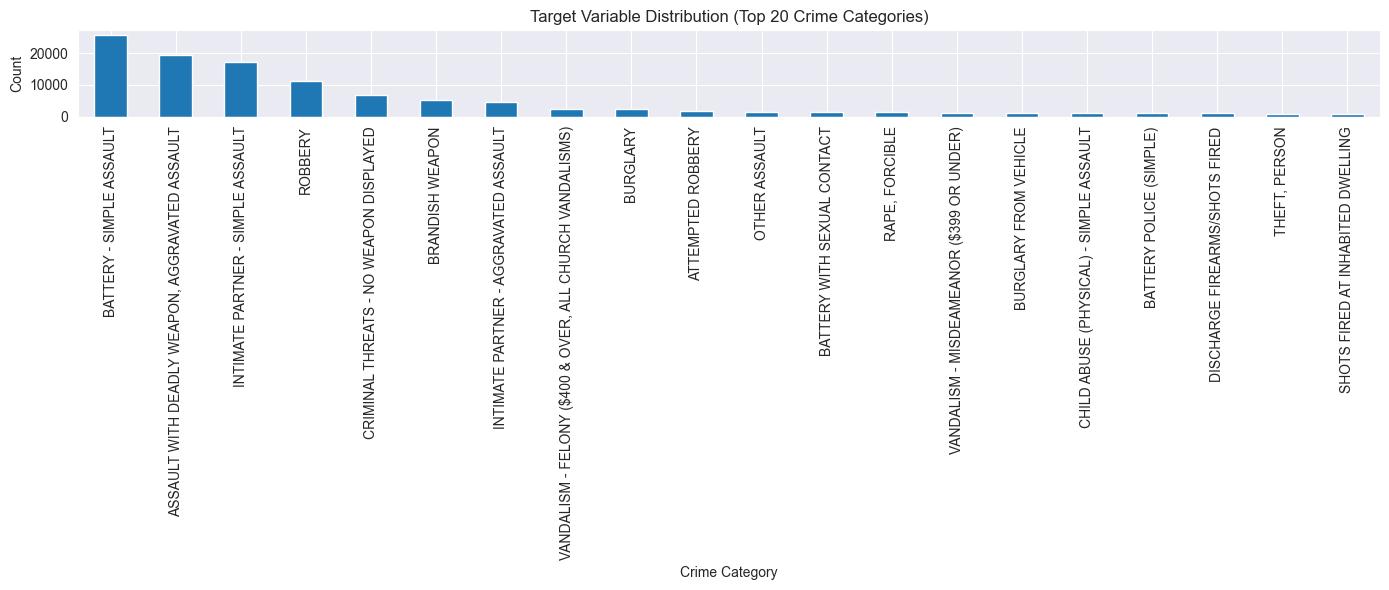

In [23]:
  # Crime category column
target_var = "Crm Cd Desc"

plt.figure(figsize=(14,6))
df[target_var].value_counts().head(20).plot(kind='bar')
plt.title("Target Variable Distribution (Top 20 Crime Categories)")
plt.xlabel("Crime Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

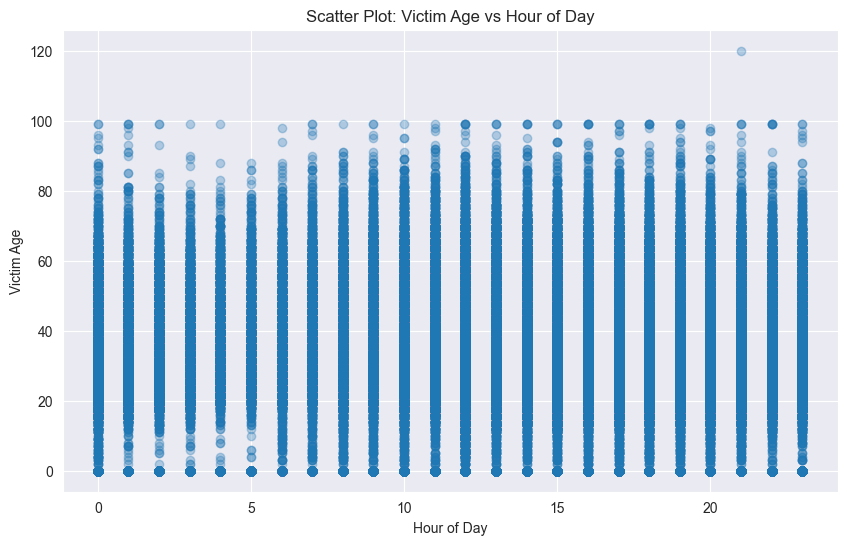

In [24]:

plt.figure(figsize=(10,6))
plt.scatter(df['HOUR'], df['Vict Age'], alpha=0.3)
plt.title("Scatter Plot: Victim Age vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Victim Age")
plt.show()

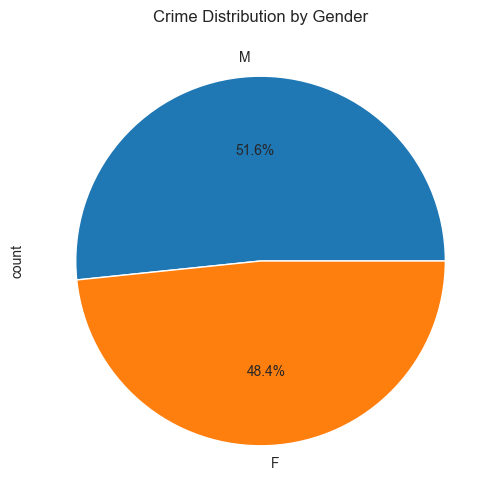

In [25]:
df_gender = df[df["Vict Sex"].isin(["M", "F"])]
gender_counts = df_gender["Vict Sex"].value_counts()
plt.figure(figsize=(6,6))
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Crime Distribution by Gender")
plt.show()


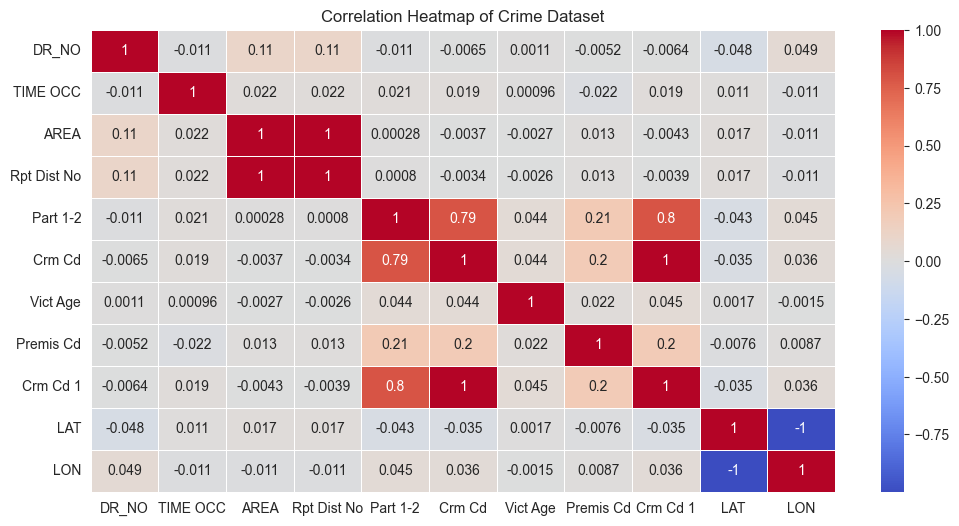

In [26]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Crime Dataset")
plt.show()


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = df.copy()

# 1. Remove columns that are fully empty or constant
df = df.dropna(axis=1, how='all')

# 2. Fill all missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

# 3. Convert all "object" columns into strings (prevents dtype conflicts)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str)

# 4. Label encode ALL string columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 5. Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# 6. Fill NaNs created after coercion
df = df.fillna(0)

# 7. Define target column
target_col = "Vict Sex"  # CHANGE if needed

y = df[target_col].astype(int)
X = df.drop(columns=[target_col]).astype(float)

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 9. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))


# Applying Machine Learning Algorithms

# Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Train logistic regression (multiclass)
log_clf = LogisticRegression(random_state=42, max_iter=500, multi_class='auto')
log_clf.fit(X_train, y_train)

# Predictions
y_pred = log_clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


# If dataset imbalance → use weighted
print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))


# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6466116980159753
Precision (weighted): 0.6452156893873402
Recall (weighted): 0.6466116980159753
F1 Score (weighted): 0.6457839950452579

Confusion Matrix:
 [[6473 4129   31]
 [3925 7322  112]
 [   6   26 1262]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.61      0.62     10633
           2       0.64      0.64      0.64     11359
           3       0.90      0.98      0.94      1294

    accuracy                           0.65     23286
   macro avg       0.72      0.74      0.73     23286
weighted avg       0.65      0.65      0.65     23286



In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Train KNN
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

# Predictions
y_pred = knn_clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6183973202782788
Precision (weighted): 0.6196624433121659
Recall (weighted): 0.6183973202782788
F1 Score (weighted): 0.6188575701004362

Confusion Matrix:
 [[6529 4065   39]
 [4231 6940  188]
 [ 116  247  931]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.61      0.61     10633
           2       0.62      0.61      0.61     11359
           3       0.80      0.72      0.76      1294

    accuracy                           0.62     23286
   macro avg       0.67      0.65      0.66     23286
weighted avg       0.62      0.62      0.62     23286



In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Train SVM
svm_clf = SVC(kernel='rbf', probability=True)
svm_clf.fit(X_train, y_train)

# Predictions
y_pred = svm_clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.664734175040797
Precision (weighted): 0.6638396116887016
Recall (weighted): 0.664734175040797
F1 Score (weighted): 0.6634236073450485

Confusion Matrix:
 [[6490 4098   45]
 [3321 7801  237]
 [  26   80 1188]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.61      0.63     10633
           2       0.65      0.69      0.67     11359
           3       0.81      0.92      0.86      1294

    accuracy                           0.66     23286
   macro avg       0.71      0.74      0.72     23286
weighted avg       0.66      0.66      0.66     23286



In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Train Decision Tree (supports multiclass automatically)
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Predictions
y_pred = dt_clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


# Weighted metrics (recommended if dataset is imbalanced)
print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6215751953963755
Precision (weighted): 0.6219589088004269
Recall (weighted): 0.6215751953963755
F1 Score (weighted): 0.6217547363337367

Confusion Matrix:
 [[6335    1 4270   27]
 [   0    0    0    0]
 [4365    2 6939   53]
 [  34    0   60 1200]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.60      0.59     10633
           1       0.00      0.00      0.00         0
           2       0.62      0.61      0.61     11359
           3       0.94      0.93      0.93      1294

    accuracy                           0.62     23286
   macro avg       0.54      0.53      0.53     23286
weighted avg       0.62      0.62      0.62     23286



<p>Generate Crime Hotstops Map using kMeans Clustering</P>

In [32]:
# ------------------------------
# 1. BASIC CLEANING
# ------------------------------

# Convert date columns
df_crime['DATE_OCC'] = pd.to_datetime(df_crime['DATE OCC'], errors='coerce')
df_crime['DATE_RPTD'] = pd.to_datetime(df_crime['Date Rptd'], errors='coerce')

# ------------------------------
# 2. CONVERT TIME OCC TO HOUR (0–23)
# ------------------------------

def convert_time_to_hour(t):
    try:
        t = int(t)
        return t // 100    # 2230 -> 22 | 30 -> 0 | 955 -> 9
    except:
        return None

df_crime['HOUR_OCC'] = df_crime['TIME OCC'].apply(convert_time_to_hour)
df_crime['HOUR_OCC'] = df_crime['HOUR_OCC'].astype('Int64')

# ------------------------------
# 3. CLEAN LAT/LON COLUMNS
# ------------------------------

df_crime['LAT'] = pd.to_numeric(df_crime['LAT'], errors='coerce')
df_crime['LON'] = pd.to_numeric(df_crime['LON'], errors='coerce')

# Remove rows without coords
df_crime = df_crime.dropna(subset=['LAT', 'LON', 'HOUR_OCC'])

# Remove invalid coordinates (0,0)
df_crime = df_crime[(df_crime['LAT'] != 0) & (df_crime['LON'] != 0)]

# ------------------------------
# 4. CREATE CRIME SEVERITY WEIGHT
# ------------------------------

severity_map = {
    121: 5, 230: 5,
    210: 4,
    330: 3, 341: 3,
    624: 2, 740: 2,
    745: 1, 442: 1, 440: 1
}

df_crime['CRIME_WEIGHT'] = df_crime['Crm Cd'].map(severity_map).fillna(1)

# ------------------------------
# 5. SELECT ONLY RELEVANT COLUMNS FOR CLUSTERING
# ------------------------------

cols_to_keep = [
    'DATE_OCC', 'HOUR_OCC',
    'LAT', 'LON',
    'Crm Cd', 'Crm Cd Desc',
    'Part 1-2', 'AREA NAME', 'Premis Desc',
    'CRIME_WEIGHT'
]

df_clean = df_crime[cols_to_keep].copy()

# ------------------------------
# 6. PRINT FINAL CLEANED DATA
# ------------------------------

print("Final cleaned dataframe shape:", df_clean.shape)
print(df_clean.head())


Final cleaned dataframe shape: (315548, 10)
    DATE_OCC  HOUR_OCC      LAT       LON  Crm Cd  \
0 2020-01-08        22  34.0141 -118.2978     624   
1 2020-01-01         3  34.0459 -118.2545     624   
2 2020-09-16        12  33.9739 -118.2630     745   
3 2020-01-01        17  34.1685 -118.4019     745   
4 2020-01-01         4  34.2198 -118.4468     740   

                                         Crm Cd Desc  Part 1-2    AREA NAME  \
0                           BATTERY - SIMPLE ASSAULT         2    Southwest   
1                           BATTERY - SIMPLE ASSAULT         2      Central   
2           VANDALISM - MISDEAMEANOR ($399 OR UNDER)         2  77th Street   
3           VANDALISM - MISDEAMEANOR ($399 OR UNDER)         2  N Hollywood   
4  VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...         2      Mission   

                                    Premis Desc  CRIME_WEIGHT  
0                        SINGLE FAMILY DWELLING           2.0  
1                                 

In [33]:
!pip install plotly -q

import plotly.express as px


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [34]:
import pandas as pd
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go


def compute_hourly_hotspots(df, k=5, min_cluster_size=5):
    hotspots = []

    for hour in range(24):
        df_hour = df[df['HOUR_OCC'] == hour]

        if len(df_hour) < k:
            continue

        coords = df_hour[['LAT', 'LON']].values
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(coords)
        centers = kmeans.cluster_centers_

        for cid in range(k):
            cluster_points = df_hour.iloc[labels == cid]

            if len(cluster_points) < min_cluster_size:
                continue

            center_lat, center_lon = centers[cid]
            crime_dist = cluster_points['Crm Cd Desc'].value_counts().to_dict()

            hotspots.append({
                'HOUR': hour,
                'CLUSTER_ID': cid,
                'CENTER_LAT': center_lat,
                'CENTER_LON': center_lon,
                'NUM_POINTS': len(cluster_points),
                'TOTAL_WEIGHT': cluster_points['CRIME_WEIGHT'].sum(),
                'TOP_CRIME': max(crime_dist, key=crime_dist.get),
                'CRIME_DIST': crime_dist,
                'K_VALUE': k  # <--- IMPORTANT: track which K these belong to
            })

    return pd.DataFrame(hotspots)

In [35]:
def compute_hotspots_multiple_k(df, k_list=[3, 5, 8, 10]):
    all_df = []

    for k in k_list:
        print("Generating hotspots for K =", k)
        df_k = compute_hourly_hotspots(df, k=k)
        df_k["HOUR_LABEL"] = df_k["HOUR"].apply(lambda h: f"{h:02d}:00")

        # ADD MISSING COLUMNS SO PLOTLY DOES NOT CRASH
        df_k["SEVERITY_LEVEL"] = df_k["TOTAL_WEIGHT"]          # temporary, overwritten later
        df_k["DISPLAY_TOP_CRIME"] = df_k["TOP_CRIME"]          # temporary, overwritten later

        all_df.append(df_k)

    return pd.concat(all_df, ignore_index=True)

In [36]:
k_values = [3, 5, 8, 10]   # <-- precompute any K you want here
hotspots_df = compute_hotspots_multiple_k(df_clean, k_values)

Generating hotspots for K = 3
Generating hotspots for K = 5
Generating hotspots for K = 8
Generating hotspots for K = 10


In [37]:
def map_severity(score):
    if score < 50:
        return "LOW"
    elif score < 150:
        return "MEDIUM"
    elif score < 400:
        return "HIGH"
    else:
        return "CRITICAL"

hotspots_df["SEVERITY_LEVEL"] = hotspots_df["TOTAL_WEIGHT"].apply(map_severity)

hotspots_df['DISPLAY_TOP_CRIME'] = hotspots_df['TOP_CRIME'].str.title().str.replace("-", " ").str.strip()



In [38]:
def build_single_k_figure(df_k):
    # -------------------------------------------------------------
    # Build summary table for each hour    (your logic)
    # -------------------------------------------------------------
    hour_summary = df_k.groupby("HOUR").agg(
        TOTAL_INCIDENTS=("NUM_POINTS", "sum"),
        TOTAL_CLUSTERS=("CLUSTER_ID", "count"),
        TOP_CRIME=("DISPLAY_TOP_CRIME", lambda x: x.value_counts().index[0])
    ).reset_index()

    hour_summary["HOUR_LABEL"] = hour_summary["HOUR"].apply(lambda h: f"{h:02d}:00")

    # -------------------------------------------------------------
    # BASE FIGURE  (your px.scatter_mapbox config)
    # -------------------------------------------------------------
    fig = px.scatter_mapbox(
        df_k,
        lat="CENTER_LAT",
        lon="CENTER_LON",
        size="NUM_POINTS",
        color="TOTAL_WEIGHT",
        color_continuous_scale="YlOrRd",
        size_max=45,
        zoom=9,
        opacity=0.85,
        animation_frame="HOUR",
        hover_data={
            "HOUR_LABEL": False,
            "NUM_POINTS": True,
            "SEVERITY_LEVEL": True,
            "DISPLAY_TOP_CRIME": True,
            "TOTAL_WEIGHT": False,
            "CENTER_LAT": False,
            "CENTER_LON": False
        }
    )

    # -------------------------------------------------------------
    # TITLE + HEIGHT FIX   (your layout)
    # -------------------------------------------------------------
    fig.update_layout(
        mapbox_style="carto-positron",
        mapbox_center={"lat": 34.05, "lon": -118.25},
        title={
            "text": "<b>LA Crime Hotspots by Hour</b>",
            "x": 0.5,
            "y": 0.97,
            "xanchor": "center",
            "yanchor": "top",
            "font": dict(size=26)
        },
        height=800,
        margin=dict(l=0, r=0, t=100, b=60),
        coloraxis_colorbar=dict(title="Severity Score"),
    )

    # -------------------------------------------------------------
    # INITIAL HOVER TEMPLATE  (your hover)
    # -------------------------------------------------------------
    fig.update_traces(
        customdata=df_k[["HOUR_LABEL", "NUM_POINTS", "SEVERITY_LEVEL", "DISPLAY_TOP_CRIME"]],
        hovertemplate=(
            "<b>Hour:</b> %{customdata[0]}<br>"
            "<b>Incidents:</b> %{customdata[1]}<br>"
            "<b>Severity:</b> %{customdata[2]}<br>"
            "<b>Top Crime:</b> %{customdata[3]}<extra></extra>"
        )
    )

    # -------------------------------------------------------------
    # STATIC PLACEHOLDER FOR HOUR LABEL + SUMMARY PANEL  (your annotations)
    # -------------------------------------------------------------
    # Use the first row as starting summary (same behavior as your loc[0,...])
    initial_row = hour_summary.iloc[0]

    fig.update_layout(
        annotations=[
            # Hour label (existing)
            dict(
                x=0.5, y=1.05,
                xref="paper", yref="paper",
                showarrow=False,
                text="<b>Hour: 00:00</b>",
                font=dict(size=20)
            ),
            # Summary Panel (static initial)
            dict(
                x=0.02, y=0.95,
                xref="paper", yref="paper",
                showarrow=False,
                align="left",
                bgcolor="rgba(0,0,0,0.6)",
                bordercolor="white",
                borderwidth=1,
                borderpad=4,
                text=(
                    f"<b>Hour: 00:00</b><br>"
                    f"Total Crimes: {int(initial_row['TOTAL_INCIDENTS'])}<br>"
                    # f"Clusters: {int(initial_row['TOTAL_CLUSTERS'])}<br>"
                    f"Top Crime: {initial_row['TOP_CRIME']}"
                ),
                font=dict(size=16, color="white")
            )
        ]
    )

    # -------------------------------------------------------------
    # FRAME-BY-FRAME HOVER + SUMMARY UPDATE  (your original loop)
    # -------------------------------------------------------------
    for frame in fig.frames:
        # hour dataframe
        frame_df = df_k[df_k["HOUR"] == int(frame.name)].reset_index(drop=True)

        # hover logic (unchanged)
        for trace in frame.data:
            n_points = len(trace.lat)
            trace.customdata = [
                [
                    frame_df.loc[i, "HOUR_LABEL"],
                    frame_df.loc[i, "NUM_POINTS"],
                    frame_df.loc[i, "SEVERITY_LEVEL"],
                    frame_df.loc[i, "DISPLAY_TOP_CRIME"]
                ]
                for i in range(n_points)
            ]
            trace.hovertemplate = (
                "<b>Incidents:</b> %{customdata[1]}<br>"
                "<b>Severity:</b> %{customdata[2]}<br>"
                "<b>Top Crime:</b> %{customdata[3]}<extra></extra>"
            )

        # ------------------------------
        # Build the TWO annotations
        # ------------------------------
        # Updated dynamic hour label
        hour_label_annotation = dict(
            x=0.5, y=1.05,
            xref="paper", yref="paper",
            showarrow=False,
            text=f"<b>Hour: {int(frame.name):02d}:00</b>",
            font=dict(size=20)
        )

        # Summary panel row for this hour
        row = hour_summary[hour_summary["HOUR"] == int(frame.name)].iloc[0]
        summary_text = (
            f"<b>Crime Summary at: {int(frame.name):02d}:00 Hr</b><br>"
            f"Total Crimes: {int(row['TOTAL_INCIDENTS'])}<br>"
            # f"Clusters: {int(row['TOTAL_CLUSTERS'])}<br>"
            f"Top Crime: {row['TOP_CRIME']}"
        )

        summary_annotation = dict(
            x=0.02, y=0.95,
            xref="paper", yref="paper",
            showarrow=False,
            align="left",
            bgcolor="rgba(0,0,0,0.6)",
            bordercolor="white",
            borderwidth=1,
            borderpad=4,
            text=summary_text,
            font=dict(size=16, color="white")
        )

        # IMPORTANT: assign both annotations
        frame.layout.annotations = [hour_label_annotation, summary_annotation]

    return fig, hour_summary

In [39]:
k_values = sorted(hotspots_df["K_VALUE"].unique())

# Use the first K as the default visible one
base_k = k_values[0]
base_df = hotspots_df[hotspots_df["K_VALUE"] == base_k].copy()

# Build your original figure for that base K
fig, _ = build_single_k_figure(base_df)

# Keep track of which traces belong to which K
k_trace_indices = {
    base_k: list(range(len(fig.data)))    # all existing traces belong to base_k initially
}

# Give base traces a name for legend clarity
for i in k_trace_indices[base_k]:
    fig.data[i].name = f"K={base_k}"

# For each ADDITIONAL K, build the same figure and merge its traces & frames into the main fig
for k in k_values[1:]:
    df_k = hotspots_df[hotspots_df["K_VALUE"] == k].copy()

    temp_fig, _ = build_single_k_figure(df_k)

    # 1) Add traces from this K to main figure, hidden by default
    start_idx = len(fig.data)
    for tr in temp_fig.data:
        tr.visible = False           # start hidden
        tr.name = f"K={k}"
        fig.add_trace(tr)
    end_idx = len(fig.data)
    k_trace_indices[k] = list(range(start_idx, end_idx))

    # 2) Merge the frame data: for each hour frame, append the traces for this K
    frames_by_name = {fr.name: fr for fr in temp_fig.frames}
    for master_fr in fig.frames:
        if master_fr.name in frames_by_name:
            # extend the data list with the traces for this K/hour
            master_fr.data += frames_by_name[master_fr.name].data


# DROPDOWN BUTTONS TO TOGGLE K (NEW)


buttons = []
n_traces_total = len(fig.data)

for k in k_values:
    visible = [False] * n_traces_total

    # turn ON only traces for this K
    for idx in k_trace_indices[k]:
        visible[idx] = True

    buttons.append(
        dict(
            label=f"{k} clusters",
            method="update",
            args=[
                {"visible": visible},   # which traces are visible
                {}                      # layout updates (none needed; your annotations are hour-based)
            ],
        )
    )

# Get the existing updatemenus (this includes the play/pause controls)
existing_updatemenus = list(fig.layout.updatemenus) if fig.layout.updatemenus else []

# Our new dropdown menu for K selection
k_dropdown_menu = dict(
    type="dropdown",
    direction="down",
    showactive=True,
    x=0.90,          # near top-right
    y=1.18,
    xanchor="right",
    yanchor="top",
    buttons=buttons
)

# Append the dropdown to the existing updatemenus (instead of replacing them)
fig.update_layout(
    updatemenus=existing_updatemenus + [k_dropdown_menu]
)



fig.show()

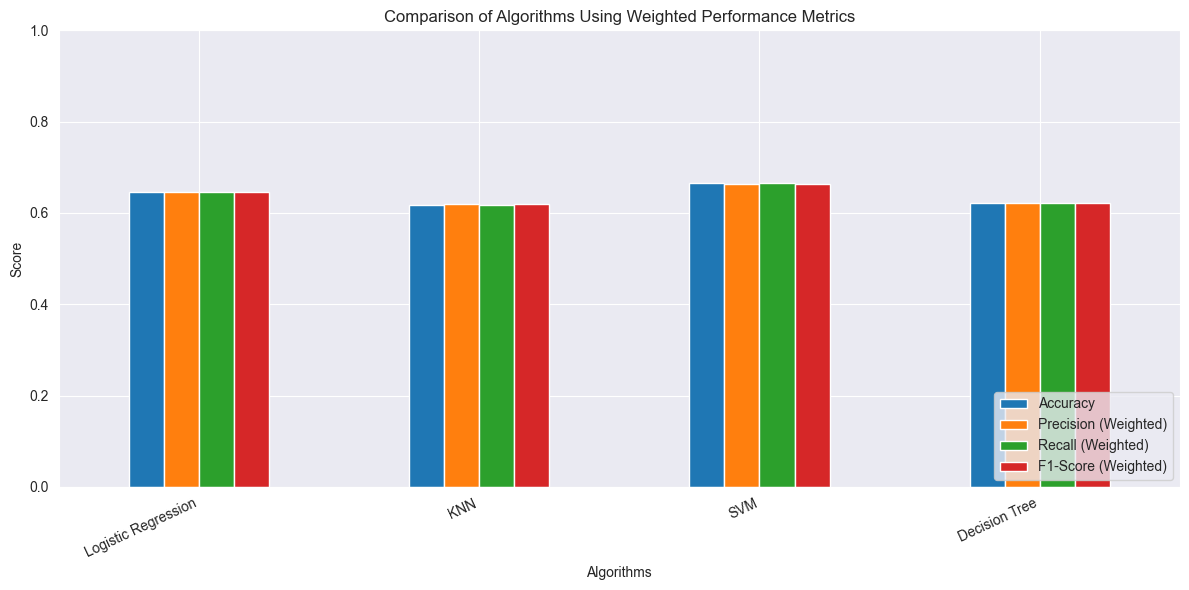

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# 1) Create model_scores dict
# ----------------------------
model_scores = {}


# ----------------------------
# 2) Metric function (weighted)
# ----------------------------
def store_weighted_scores(model_name, y_true, y_pred):
    model_scores[model_name] = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (Weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score (Weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


# ----------------------------
# 3) Train & Evaluate Models
# ----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    store_weighted_scores(name, y_test, y_pred)

# ----------------------------
# 4) Create DataFrame
# ----------------------------
scores_df = pd.DataFrame(model_scores).T

# ----------------------------
# 5) Single Combined Graph
# ----------------------------
scores_df.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Comparison of Algorithms Using Weighted Performance Metrics")
plt.xlabel("Algorithms")
plt.ylabel("Score")
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
